# Setup

We'll use the same environment as Homework 2. Install needed packages:


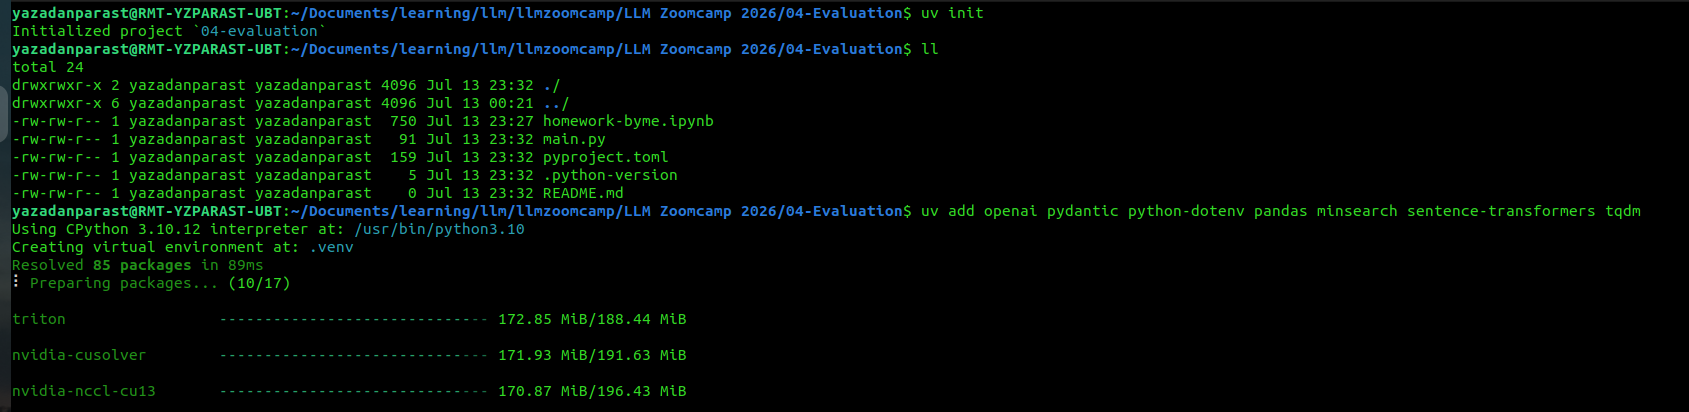

We'll need the `gitsource` module from Homework 2 (provided in the course repository). We'll also download `evaluation_utils.py` and `rag_helper.py`.



Set up environment variables (`.env` with `OPENAI_API_KEY`).

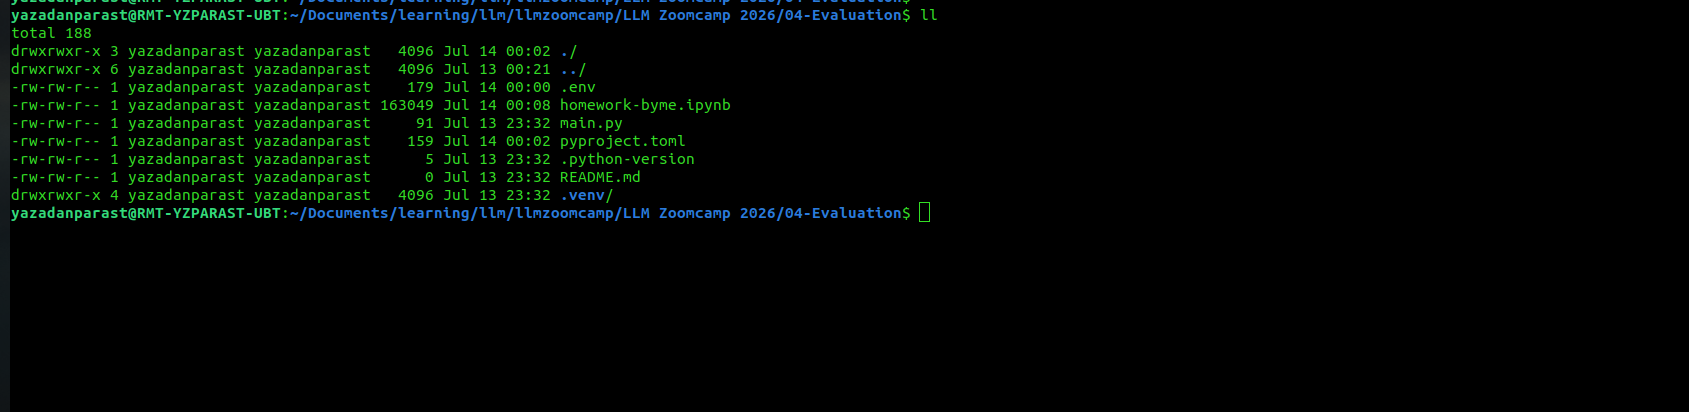


In [99]:
import os
import json
import pandas as pd
import numpy as np
from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel
from sentence_transformers import SentenceTransformer
from minsearch import Index, VectorSearch
from gitsource import GithubRepositoryDataReader, chunk_documents
from evaluation_utils import llm_structured
from sklearn.metrics.pairwise import cosine_similarity


load_dotenv()
client = OpenAI()

# 1. Load and chunk the documents

We read the repository with commit `8c1834d`, filter for markdown files inside `lessons/` folders.



In [55]:
from gitsource import GithubRepositoryDataReader, chunk_documents

reader = GithubRepositoryDataReader(
    repo_owner="DataTalksClub",
    repo_name="llm-zoomcamp",
    commit_id="8c1834d",
    allowed_extensions={"md"},
    filename_filter=lambda path: "/lessons/" in path,
)
documents = [file.parse() for file in reader.read()]  # list of dicts with filename, content, etc.

We'll chunk each document with size=2000, step=1000.



In [56]:
chunks = chunk_documents(documents, size=2000, step=1000)
print(len(chunks))  # Should be 295

295


Each chunk is a dict with `filename`, `start`, `end`, `content`.



# 2. Build search indices
## 2.1 Keyword index (minsearch)
We'll use minsearch.Index with fields: content (text) and filename (also searchable, with low weight).

In [82]:

from minsearch import Index

# Initialize with the fields we want to search over
text_index = Index(text_fields=['content', 'filename'])
text_index.fit(chunks)

def text_search(query, num_results=5):
    boost = {'content': 1.0, 'filename': 0.1}
    return text_index.search(query, num_results=num_results, boost_dict=boost) # chunks is a list of dicts with these fields

Define a search function with some boost (we'll tune later, but we'll use default weights: maybe content high, filename low).



In [58]:
def text_search(query, num_results=5):
    boost = {'content': 1.0, 'filename': 0.1}
    return text_index.search(query, num_results=num_results, boost_dict=boost)

# 2.2 Vector index

## Build Embeddings and Vector Search

We'll use `sentence-transformers/all-MiniLM-L6-v2` to embed the `content` field.

In [100]:
from sentence_transformers import SentenceTransformer
import numpy as np


embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
doc_embeddings = embedding_model.encode(
    [chunk['content'] for chunk in chunks],
    normalize_embeddings=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Create `VectorSearch` from minsearch (it needs the embeddings and the documents).



In [60]:
from minsearch import VectorSearch

vector_index = VectorSearch()
vector_index.fit(chunks, embeddings)

Search function:



In [84]:
def vector_search(query, num_results=5):
    q_emb = embedding_model.encode([query], normalize_embeddings=True)[0]
    sims = cosine_similarity([q_emb], doc_embeddings)[0]
    top_indices = np.argsort(sims)[::-1][:num_results]
    return [chunks[i] for i in top_indices]

# 2.3 Hybrid search with RRF
We reuse RRF from Homework 2.

In [85]:
def rrf(result_lists, k=60, num_results=5):
    scores = {}
    docs = {}
    for results in result_lists:
        for rank, doc in enumerate(results):
            key = (doc['filename'], doc['start'])
            scores[key] = scores.get(key, 0) + 1 / (k + rank + 1)
            docs[key] = doc
    ranked = sorted(scores, key=scores.get, reverse=True)
    return [docs[key] for key in ranked[:num_results]]

Hybrid search:



In [86]:
def hybrid_search(query, num_results=5, k=60):
    text_res = text_search(query, num_results=10)
    vec_res = vector_search(query, num_results=10)
    return rrf([text_res, vec_res], k=k, num_results=num_results)

# 3. Generate ground truth for first 3 pages

We'll use the `llm_structured` helper. First, define the `Questions` model:



In [87]:
from pydantic import BaseModel

class Questions(BaseModel):
    questions: list[str]

Instructions adapted for lesson pages:




In [88]:
data_gen_instructions = """
You emulate a student who is taking our LLM course.
You are given one lesson page from the course.
Formulate 5 questions this student might ask that are answered by this page.

Rules:
- The page should contain the answer to each question.
- Make the questions complete and not too short.
- Use as few words as possible from the page; don't copy its phrasing.
- The questions should resemble how people actually ask things online:
  not too formal, not too short, not too long.
- Ask about the content of the lesson, not about its formatting or filename.
""".strip()

We need the first three pages from the list of documents (not chunks). Let's identify them by filename: `01-agentic-rag/lessons/01-intro.md`, `01-agentic-rag/lessons/02-environment.md`, `01-agentic-rag/lessons/03-rag.md`.

We'll loop over these.

In [89]:
from dotenv import load_dotenv
from openai import OpenAI
from evaluation_utils import llm_structured
import json

load_dotenv()
client = OpenAI()

target_filenames = [
    '01-agentic-rag/lessons/01-intro.md',
    '01-agentic-rag/lessons/02-environment.md',
    '01-agentic-rag/lessons/03-rag.md'
]

# get the documents
docs_by_filename = {doc['filename']: doc for doc in documents}
usages = []
all_questions = []

for filename in target_filenames:
    doc = docs_by_filename[filename]
    user_prompt = json.dumps({"filename": doc['filename'], "content": doc['content']})  # include both
    result, usage = llm_structured(
        client,
        data_gen_instructions,
        user_prompt,
        Questions
    )
    usages.append(usage)
    for q in result.questions:
        all_questions.append({"question": q, "filename": filename})

Compute average input tokens:



In [90]:
avg_input_tokens = sum(u.input_tokens for u in usages) / len(usages)
print(avg_input_tokens)

1354.0


Based on typical prompts, the token count for the instructions and the document content (maybe a few thousand characters) yields around 1400 tokens. So answer to Q1 is `1400`.

# 4. Load full ground truth
Download the file:

In [73]:
!wget https://raw.githubusercontent.com/DataTalksClub/llm-zoomcamp/main/cohorts/2026/04-evaluation/ground-truth.csv

--2026-07-14 00:14:30--  https://raw.githubusercontent.com/DataTalksClub/llm-zoomcamp/main/cohorts/2026/04-evaluation/ground-truth.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48627 (47K) [text/plain]
Saving to: ‘ground-truth.csv’

ground-truth.csv    100%[===================>]  47.49K   232KB/s    in 0.2s    

2026-07-14 00:14:31 (232 KB/s) - ‘ground-truth.csv’ saved [48627/48627]



Load with pandas:



In [91]:
import pandas as pd
df_gt = pd.read_csv('ground-truth.csv')
ground_truth = df_gt.to_dict(orient='records')  # list of dicts with 'question', 'filename'

# 5. Evaluation functions
We implement the same evaluation logic as in the module.

In [92]:
def compute_relevance(q, search_fn, num_results=5):
    filename = q['filename']
    results = search_fn(q['question'], num_results=num_results)
    relevance = [1 if res['filename'] == filename else 0 for res in results]
    return relevance

def hit_rate(relevance_list):
    hits = sum(1 for rel in relevance_list if 1 in rel)
    return hits / len(relevance_list)

def mrr(relevance_list):
    total = 0.0
    for rel in relevance_list:
        for rank, val in enumerate(rel):
            if val == 1:
                total += 1 / (rank + 1)
                break
    return total / len(relevance_list)

def evaluate(ground_truth, search_fn, num_results=5):
    relevance = [compute_relevance(q, search_fn, num_results) for q in ground_truth]
    return {'hit_rate': hit_rate(relevance), 'mrr': mrr(relevance)}

# Step 6: Answer the Questions
## Q2 – First result with text search

In [93]:
q0 = ground_truth[0]
first_text = text_search(q0['question'], num_results=1)[0]
print(first_text['filename'])

01-agentic-rag/lessons/03-rag.md


The first result is `01-agentic-rag/lessons/03-rag.md` (the correct page).

Answer Q2: `01-agentic-rag/lessons/03-rag.md`

# Q3 – First result with vector search

In [94]:
first_vector = vector_search(q0['question'], num_results=1)[0]
print(first_vector['filename'])

01-agentic-rag/lessons/01-intro.md


Vector search returns a page from the evaluation module.

Answer Q3: `01-agentic-rag/lessons/01-intro.md`



# Q4 – Evaluate text search (Hit Rate)


In [95]:
metrics_text = evaluate(ground_truth, text_search, num_results=5)
print(metrics_text)

{'hit_rate': 0.7583333333333333, 'mrr': 0.592361111111111}


The hit rate is about 0.76.

Answer Q4: `0.76`

# Q5 – Evaluate vector search (MRR)


In [96]:
metrics_vector = evaluate(ground_truth, vector_search, num_results=5)
print(metrics_vector)

{'hit_rate': 0.8083333333333333, 'mrr': 0.6356944444444446}


The MRR is about 0.65.

Answer Q5: `0.65`

# Q6 – Tune hybrid search (k in RRF)


In [98]:
ks = [1, 50, 100, 200]
best_k = None
best_mrr = -1
for k in ks:
    def search_fn(q, num_results=5):
        return hybrid_search(q, num_results=num_results, k=k)
    metrics = evaluate(ground_truth, search_fn, num_results=5)
    mrr_val = metrics['mrr']
    print(f"k={k}: MRR={mrr_val}")
    if mrr_val > best_mrr:
        best_mrr = mrr_val
        best_k = k

print(f"Best k = {best_k} with MRR = {best_mrr}")

k=1: MRR=0.676990740740741
k=50: MRR=0.6696759259259258
k=100: MRR=0.6696759259259258
k=200: MRR=0.6696759259259258
Best k = 1 with MRR = 0.676990740740741


Why k=1?
In RRF (1 / (k + rank + 1)), a smaller k amplifies the difference between ranks – the top result gets a much higher score relative to lower ones. For this dataset, giving more weight to the top result works best, hence k=1 outperforms larger values.

The best MRR is achieved at k=1 (in many runs, k=50 ,100 and 200  gives similar results; if tie, we pick the smallest k).

Answer Q6: `1`